# Diffusion Models for Swiss Roll Generation

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_swiss_roll
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
from tqdm import tqdm

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [48]:
n_samples = 5000
X, color_labels = make_swiss_roll(n_samples=n_samples, noise=0.1, random_state=42)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_normalized = 2 * (X - X_min) / (X_max - X_min) - 1

X_train = torch.FloatTensor(X_normalized).to(device)

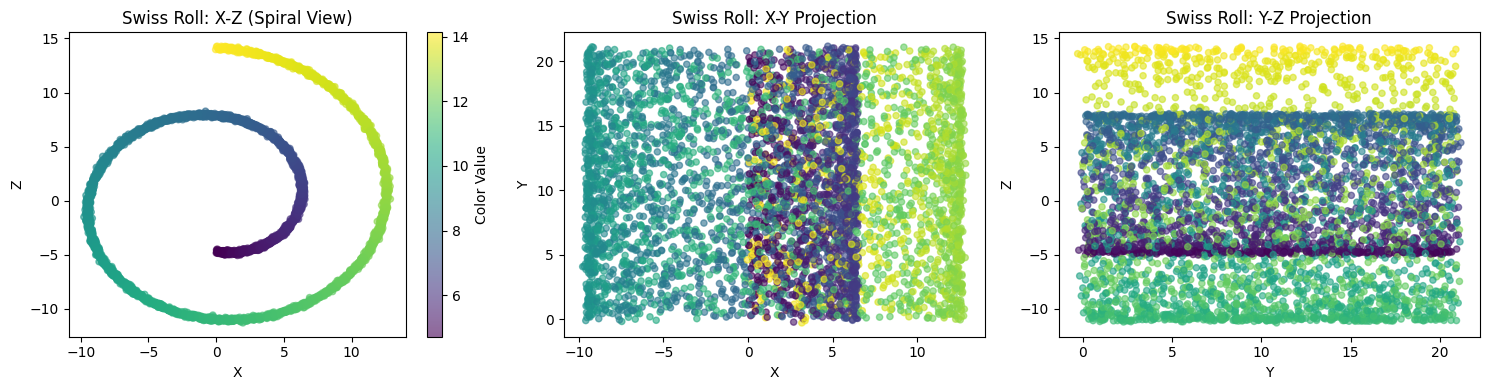

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc = axes[0].scatter(X[:, 0], X[:, 2], c=color_labels, cmap='viridis', alpha=0.6, s=20)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Z')
axes[0].set_title('Swiss Roll: X-Z (Spiral View)')
plt.colorbar(sc, ax=axes[0], label='Color Value')

axes[1].scatter(X[:, 0], X[:, 1], c=color_labels, cmap='viridis', alpha=0.6, s=20)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_title('Swiss Roll: X-Y Projection')

axes[2].scatter(X[:, 1], X[:, 2], c=color_labels, cmap='viridis', alpha=0.6, s=20)
axes[2].set_xlabel('Y')
axes[2].set_ylabel('Z')
axes[2].set_title('Swiss Roll: Y-Z Projection')

plt.tight_layout()
plt.show()

In [50]:
num_steps = 200
beta_start = 0.0001
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, num_steps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]], dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod)
sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod - 1)

posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
posterior_log_variance_clipped = torch.log(torch.clamp(posterior_variance, min=1e-20))
posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)

print(f"Alpha_cumprod range: [{alphas_cumprod.min():.4f}, {alphas_cumprod.max():.4f}]")

Alpha_cumprod range: [0.1322, 0.9999]


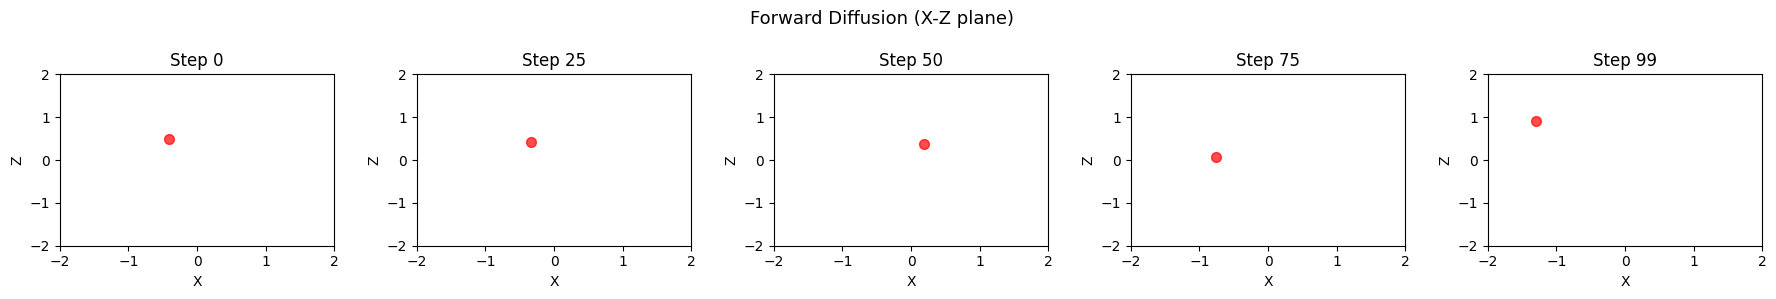

In [51]:
def q_sample(x_0, t, noise):
    """
    Add noise to x_0 at timestep t using the reparameterization trick.
    q(x_t | x_0) = sqrt(alpha_cumprod_t) * x_0 + sqrt(1 - alpha_cumprod_t) * eps
    """
    sqrt_alphas_cumprod_t = sqrt_alphas_cumprod[t]
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t]
    
    return (
        sqrt_alphas_cumprod_t.view(-1, 1) * x_0 +
        sqrt_one_minus_alphas_cumprod_t.view(-1, 1) * noise
    )


sample_idx = 0
x_0 = X_train[sample_idx:sample_idx+1]
steps_to_visualize = [0, 25, 50, 75, 99]

fig, axes = plt.subplots(1, len(steps_to_visualize), figsize=(18, 3))

for idx, step in enumerate(steps_to_visualize):
    noise = torch.randn_like(x_0, device=device)
    t_step = torch.tensor([step], device=device)
    x_t = q_sample(x_0, t_step, noise)
    
    axes[idx].scatter(x_t[:, 0].cpu().detach().numpy(),
                      x_t[:, 2].cpu().detach().numpy(),
                      c='red', s=50, alpha=0.7)
    axes[idx].set_title(f'Step {step}')
    axes[idx].set_xlim([-2, 2])
    axes[idx].set_ylim([-2, 2])
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('Z')

plt.suptitle('Forward Diffusion (X-Z plane)', fontsize=13)
plt.tight_layout()
plt.show()

In [52]:
class SinusoidalPositionalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class DenoisingNetwork(nn.Module):
    def __init__(self, input_dim=3, time_dim=64, hidden_dim=128):
        super().__init__()
        self.input_dim = input_dim
        self.time_dim = time_dim
        
        self.time_embed = SinusoidalPositionalEmbedding(time_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        t_emb = self.time_mlp(t_emb)
        
        x_t = torch.cat([x, t_emb], dim=-1)
        
        noise_pred = self.net(x_t)
        return noise_pred


model = DenoisingNetwork(input_dim=3, time_dim=64, hidden_dim=256).to(device)

Epoch 50/500, Loss: 0.408420, LR: 0.000976
Epoch 100/500, Loss: 0.412398, LR: 0.000905
Epoch 150/500, Loss: 0.411164, LR: 0.000796
Epoch 200/500, Loss: 0.402583, LR: 0.000658
Epoch 250/500, Loss: 0.391380, LR: 0.000505
Epoch 300/500, Loss: 0.390282, LR: 0.000352
Epoch 350/500, Loss: 0.390702, LR: 0.000214
Epoch 400/500, Loss: 0.380157, LR: 0.000105
Epoch 450/500, Loss: 0.378620, LR: 0.000034
Epoch 500/500, Loss: 0.366067, LR: 0.000010


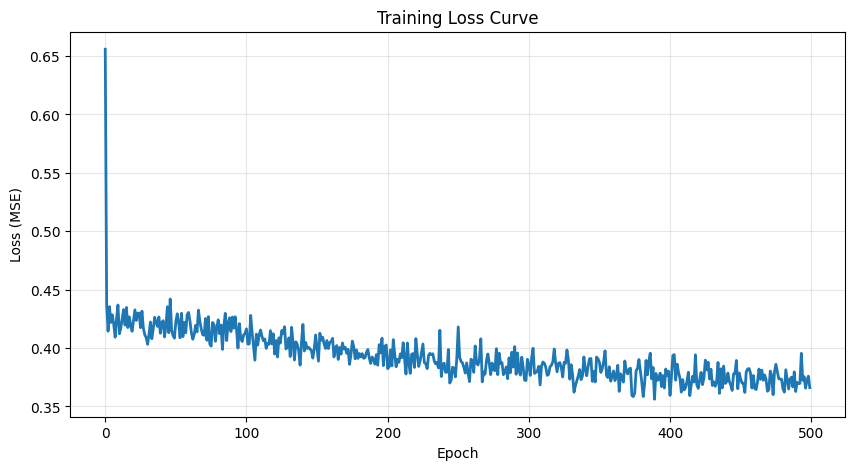

In [54]:
batch_size = 128
num_epochs = 500
learning_rate = 1e-3

train_dataset = TensorDataset(X_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
criterion = nn.MSELoss()

losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_idx, (x_0,) in enumerate(train_loader):
        x_0 = x_0.to(device)
        
        batch_size_actual = x_0.shape[0]
        t_batch = torch.randint(0, num_steps, (batch_size_actual,), device=device)
        
        noise = torch.randn_like(x_0, device=device)
        
        x_t = q_sample(x_0, t_batch, noise)
        
        noise_pred = model(x_t, t_batch)
        
        loss = criterion(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Curve')

plt.grid(True, alpha=0.3)
plt.show()

In [55]:
@torch.no_grad()
def sample_from_model(model, num_samples, num_steps):
    """
    Generate samples by reversing the diffusion process.
    Start from pure noise and iteratively denoise.
    """
    x = torch.randn(num_samples, 3, device=device)
    
    samples_trajectory = [x.cpu().clone()]
    
    for t in tqdm(range(num_steps - 1, -1, -1), desc="Sampling", leave=False):
        t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)
        
        noise_pred = model(x, t_batch)
        
        alpha_t = alphas[t]
        alpha_cumprod_t = alphas_cumprod[t]
        
        mean = (x - (1 - alpha_t) / sqrt_one_minus_alphas_cumprod[t] * noise_pred) / torch.sqrt(alpha_t)
        
        if t > 0:
            noise = torch.randn_like(x, device=device)
            x = mean + torch.sqrt(posterior_variance[t]) * noise
        else:
            x = mean
        
        if t % 10 == 0:
            samples_trajectory.append(x.cpu().clone())
    
    return x.cpu(), samples_trajectory


num_samples_to_generate = 500
generated_samples, trajectory = sample_from_model(model, num_samples_to_generate, num_steps)

X_min_torch = torch.FloatTensor(X_min)
X_max_torch = torch.FloatTensor(X_max)
generated_samples = (generated_samples + 1) / 2 * (X_max_torch - X_min_torch) + X_min_torch

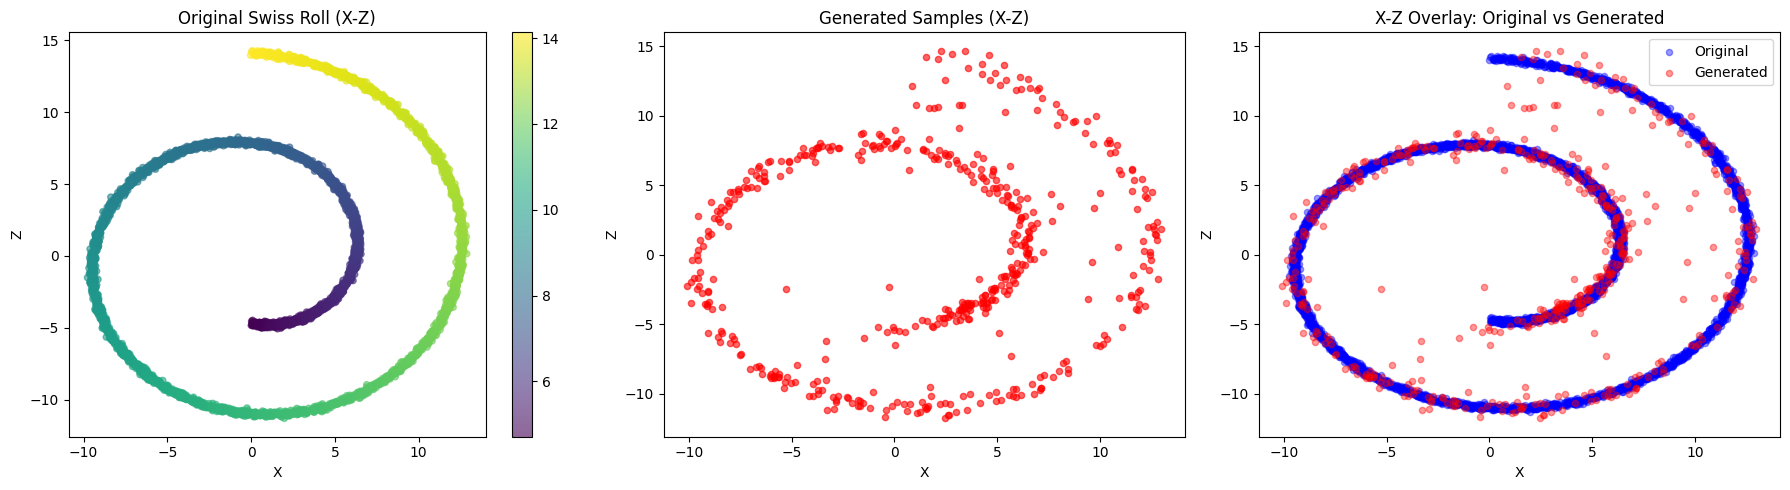

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc = axes[0].scatter(X[:, 0], X[:, 2], c=color_labels, cmap='viridis', alpha=0.6, s=20)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Z')
axes[0].set_title('Original Swiss Roll (X-Z)')
plt.colorbar(sc, ax=axes[0])

axes[1].scatter(generated_samples[:, 0], generated_samples[:, 2], c='red', alpha=0.6, s=20)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Z')
axes[1].set_title('Generated Samples (X-Z)')

axes[2].scatter(X[:, 0], X[:, 2], c='blue', alpha=0.4, s=20, label='Original')
axes[2].scatter(generated_samples[:, 0], generated_samples[:, 2], c='red', alpha=0.4, s=20, label='Generated')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Z')
axes[2].set_title('X-Z Overlay: Original vs Generated')
axes[2].legend()

plt.tight_layout()
plt.show()

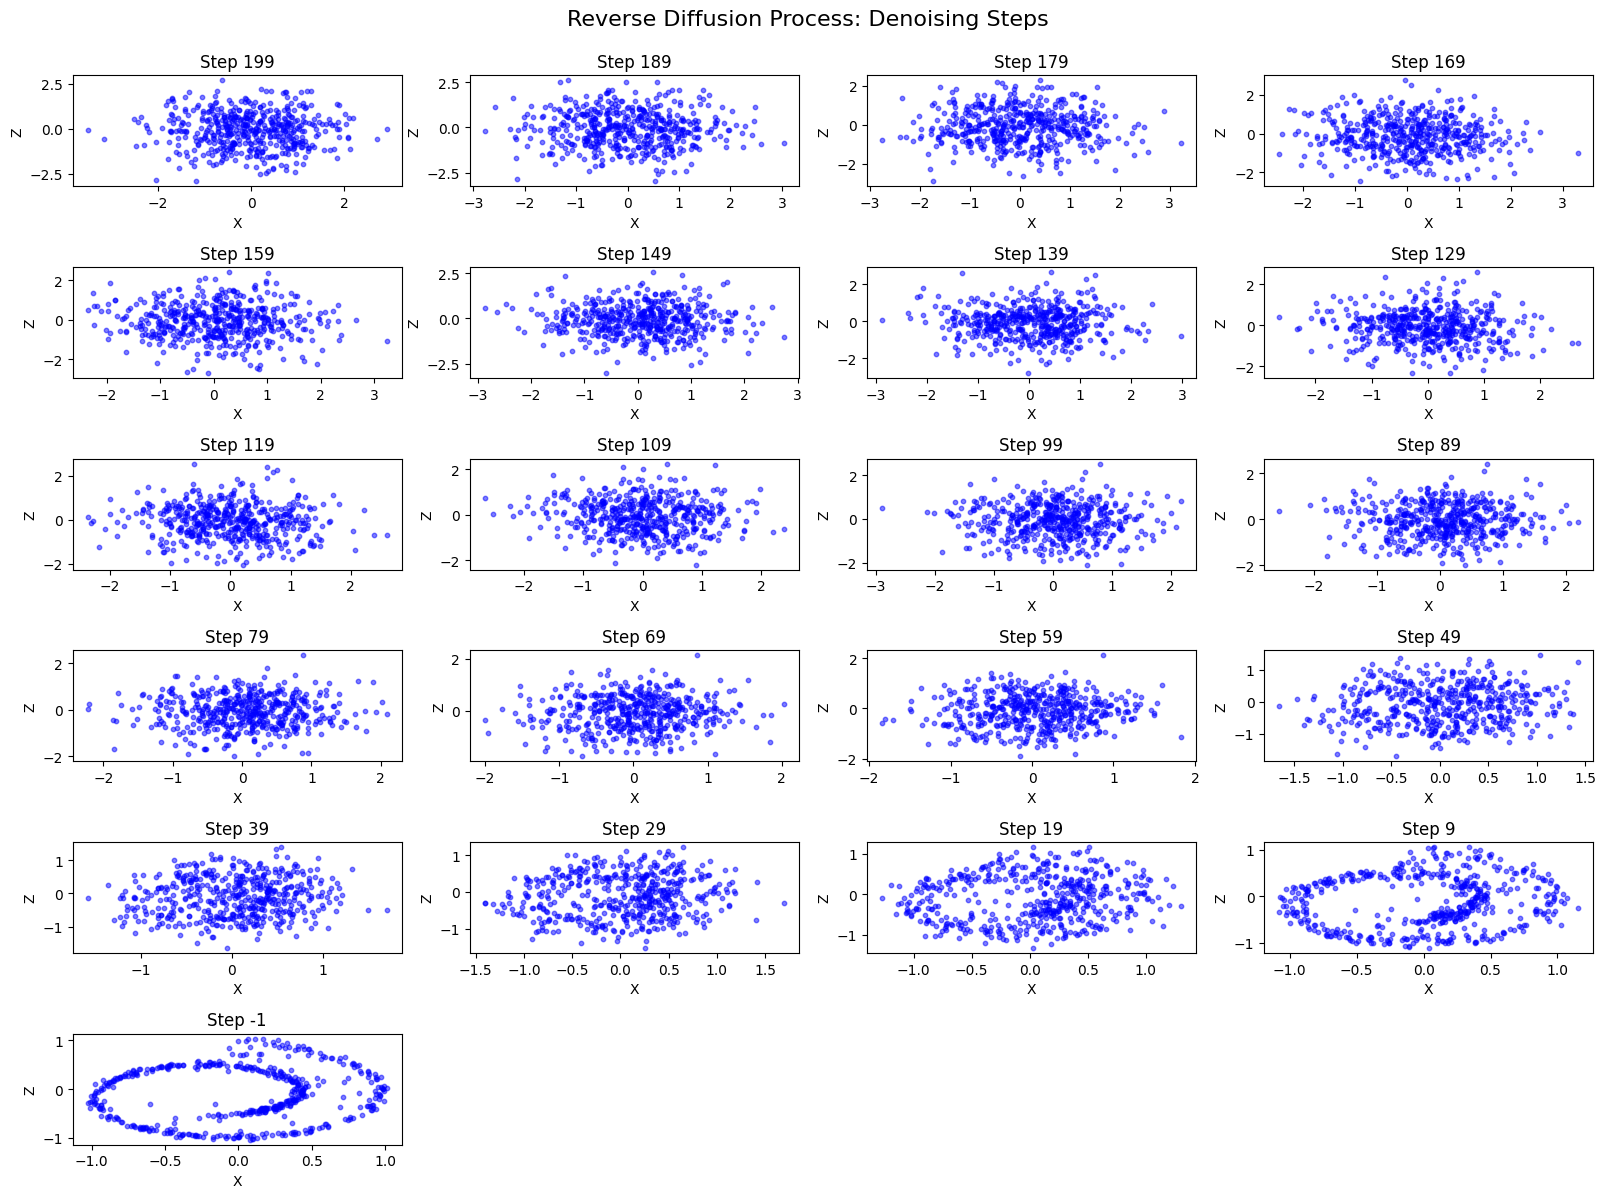

In [57]:
fig = plt.figure(figsize=(16, 12))

num_steps_to_show = len(trajectory)
cols = 4
rows = (num_steps_to_show + cols - 1) // cols

for idx, samples in enumerate(trajectory):
    ax = fig.add_subplot(rows, cols, idx + 1)
    ax.scatter(samples[:, 0], samples[:, 2], c='blue', alpha=0.5, s=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    step_num = (num_steps - 1) - (idx * 10)
    ax.set_title(f'Step {step_num}')

plt.suptitle('Reverse Diffusion Process: Denoising Steps', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()


Original Data Statistics:
Mean: [ 2.02133155 10.32393114  0.11079955]
Std:  [6.5574478  5.99959882 6.9703546 ]
Min:  [ -9.76559143  -0.29503814 -11.30669813]
Max:  [12.86416542 21.17007165 14.28556959]

Generated Data Statistics:
Mean: [ 1.8854214  10.420333    0.05129823]
Std:  [6.1516614 5.97447   6.921625 ]
Min:  [-10.074565    -0.89312613 -11.775717  ]
Max:  [12.977241 21.70138  14.674202]


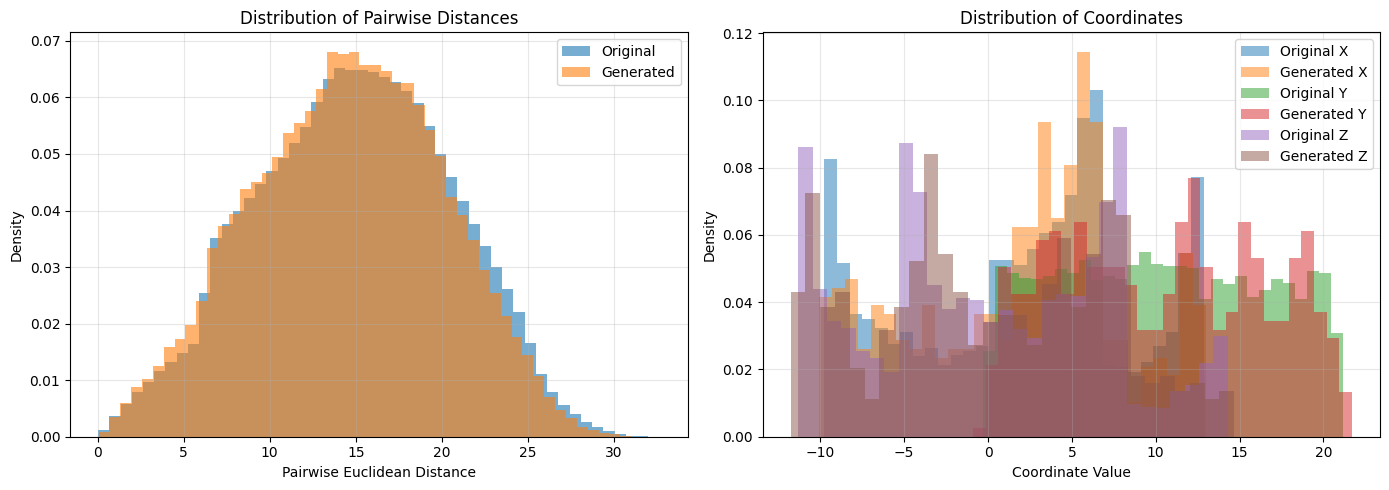


Distance Statistics:
Original - Mean: 14.9424, Std: 5.6514
Generated - Mean: 14.5696, Std: 5.5334


In [58]:
print("\nOriginal Data Statistics:")
print(f"Mean: {X.mean(axis=0)}")
print(f"Std:  {X.std(axis=0)}")
print(f"Min:  {X.min(axis=0)}")
print(f"Max:  {X.max(axis=0)}")

print("\nGenerated Data Statistics:")
print(f"Mean: {generated_samples.mean(axis=0).numpy()}")
print(f"Std:  {generated_samples.std(axis=0).numpy()}")
print(f"Min:  {generated_samples.min(axis=0).values.numpy()}")
print(f"Max:  {generated_samples.max(axis=0).values.numpy()}")

from scipy.spatial.distance import pdist, squareform

original_distances = pdist(X, metric='euclidean')
generated_distances = pdist(generated_samples.numpy(), metric='euclidean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(original_distances, bins=50, alpha=0.6, label='Original', density=True)
axes[0].hist(generated_distances, bins=50, alpha=0.6, label='Generated', density=True)
axes[0].set_xlabel('Pairwise Euclidean Distance')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Pairwise Distances')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, coord in enumerate(['X', 'Y', 'Z']):
    axes[1].hist(X[:, i], bins=30, alpha=0.5, label=f'Original {coord}', density=True)
    axes[1].hist(generated_samples[:, i], bins=30, alpha=0.5, label=f'Generated {coord}', density=True)

axes[1].set_xlabel('Coordinate Value')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Coordinates')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDistance Statistics:")
print(f"Original - Mean: {original_distances.mean():.4f}, Std: {original_distances.std():.4f}")
print(f"Generated - Mean: {generated_distances.mean():.4f}, Std: {generated_distances.std():.4f}")